### Showing results of the QM of the reaction between $OH^-$ and $CH_3Cl$

In [1]:
import megane
import numpy as np
import os
import glob
import MDAnalysis as mda
from MDAnalysis.coordinates import XYZ
from MDAnalysis.coordinates.XYZ import XYZWriter
from MDAnalysis.coordinates.XTC import XTCWriter
from MDAnalysis.coordinates.PDB import PDBWriter
import matplotlib.pyplot as plt
from pyscf import gto, scf
from pyscf.tools import cubegen
import pickle
import plotly.graph_objects as go
import pyvista as pv
import time

In [2]:
def read_cube_grid_info(path):
    with open(path, "r") as f:
        line1 = f.readline()  # comment
        line2 = f.readline()  # comment
        origin_line = f.readline().split()
        # line format: natoms origin_x origin_y origin_z
        natoms = int(origin_line[0])
        origin = tuple(map(float, origin_line[1:4])) # In atomic units (bohr)

        nx_line = f.readline().split()  # nx ax ay az
        ny_line = f.readline().split()  # ny bx by bz
        nz_line = f.readline().split()  # nz cx cy cz

    nx = int(nx_line[0]); ax = tuple(map(float, nx_line[1:4]))
    ny = int(ny_line[0]); by = tuple(map(float, ny_line[1:4]))
    nz = int(nz_line[0]); cz = tuple(map(float, nz_line[1:4]))

    return {
        "natoms": natoms,
        "origin": origin,
        "nx": nx, "ny": ny, "nz": nz,
        "ax": ax, "by": by, "cz": cz,
    }

def surf_to_mesh3d(surf):
    pts = surf.points
    faces = surf.faces.reshape(-1, 4)  # [3, a, b, c]
    i = faces[:, 1]
    j = faces[:, 2]
    k = faces[:, 3]
    return pts, i, j, k

def add_mesh_with_edges(fig, pts, i, j, k, color, opacity=0.35, name=""):
    # filled surface
    fig.add_trace(go.Mesh3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        i=i, j=j, k=k,
        color=color,
        opacity=opacity,
        flatshading=True,
        showscale=False,
        name=name
    ))

    # triangle edges as line segments
    edges = np.vstack([
        np.stack([i, j], axis=1),
        np.stack([j, k], axis=1),
        np.stack([k, i], axis=1),
    ])
    # unique undirected edges
    edges = np.sort(edges, axis=1)
    edges = np.unique(edges, axis=0)

    # build line coordinates with None separators
    x = []
    y = []
    z = []
    for a, b in edges:
        x += [pts[a, 0], pts[b, 0], None]
        y += [pts[a, 1], pts[b, 1], None]
        z += [pts[a, 2], pts[b, 2], None]

    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode="lines",
        line=dict(color="black", width=1),
        opacity=0.9,
        hoverinfo="skip",
        showlegend=False
    ))

def add_an_orbital(orbital_filename,fig,info,isofactor=0.15,opacity_plus=.95,opacity_minus=0.05):
    print('Trying to add '+orbital_filename)
    grid = pv.read(orbital_filename)
    name = grid.array_names[0]
    vals = grid[name]
    
    vmin, vmax = float(vals.min()), float(vals.max())
    m = max(abs(vmin), abs(vmax))
    print('from add_an_orbital ... m = ', m)

    iso = isofactor * m
    iso = .1
    
    surf_pos = grid.contour([+iso], scalars=name)
    surf_neg = grid.contour([-iso], scalars=name)
    
    if surf_pos.n_points > 0:
        pts, i, j, k = surf_to_mesh3d(surf_pos)
        pts = adjust_pts(pts,info)
        add_mesh_with_edges(fig, pts, i, j, k, color="red", opacity=opacity_plus, name="+")
    if surf_neg.n_points > 0:
        pts, i, j, k = surf_to_mesh3d(surf_neg)
        pts = adjust_pts(pts,info)
        add_mesh_with_edges(fig, pts, i, j, k, color="blue", opacity=opacity_minus, name="−")
    
    fig.update_layout(
        scene=dict(aspectmode="data"),
        margin=dict(l=0, r=0, t=0, b=0),
    )
    return

def adjust_pts(pts,info): # works for frame = 0
    au_conversion = 0.5292
    
    pts[:,0] *= info["ax"][0]*au_conversion
    pts[:,1] *= info["by"][1]*au_conversion
    pts[:,2] *= info["cz"][2]*au_conversion

    pts[:,0] += info["origin"][0]*au_conversion
    pts[:,1] += info["origin"][1]*au_conversion
    pts[:,2] += info["origin"][2]*au_conversion
    return pts

def add_atoms(mol,fig):
    au_conversion = 0.5292
    atom_xyz = []
    for a in mol.atom:  # mol.atom is a list like [(Z, (x,y,z)), ...] depending on PySCF version
        if isinstance(a[0], str):
            sym = a[0]
            x, y, z = a[1]
        else:
            # If entry is (Z, (x,y,z))
            sym = str(a[0])
            x, y, z = a[1]
        atom_xyz.append((sym, x, y, z))
    
    # Separate coordinates
    xs = [t[1] for t in atom_xyz]
    ys = [t[2] for t in atom_xyz]
    zs = [t[3] for t in atom_xyz]
    labels = [t[0] for t in atom_xyz]
    
    xs = np.array(xs)*au_conversion
    ys = np.array(ys)*au_conversion
    zs = np.array(zs)*au_conversion
    
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="markers+text",
        marker=dict(size=8, color="black", opacity=.9),
        text=labels,
        textposition="top center",
        name="atoms",
        showlegend=False,
    ))

### Energies

(10, 2)


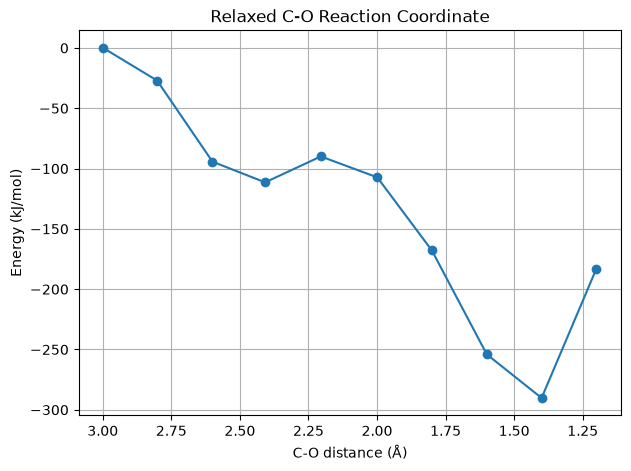

In [3]:
# Looking at the energies explicitly saved by the QM code
data = np.loadtxt('energy.txt'); print(np.shape(data))
actual_distances = data[:,0]
energies_kj=data[:,1]
plt.figure(figsize=(7,5))
plt.plot(actual_distances,energies_kj,marker="o")
plt.gca().invert_xaxis()
plt.xlabel("C-O distance (Å)")
plt.ylabel("Energy (kJ/mol)")
plt.title("Relaxed C-O Reaction Coordinate")
plt.grid(True)
plt.show()

converged SCF energy = -954.455798062968
converged SCF energy = -954.46608490269
converged SCF energy = -954.491698124215
converged SCF energy = -954.498229206348
converged SCF energy = -954.49003779024
converged SCF energy = -954.496655249875
converged SCF energy = -954.519742690638
converged SCF energy = -954.552517974914
converged SCF energy = -954.566318152383
converged SCF energy = -954.525436041181


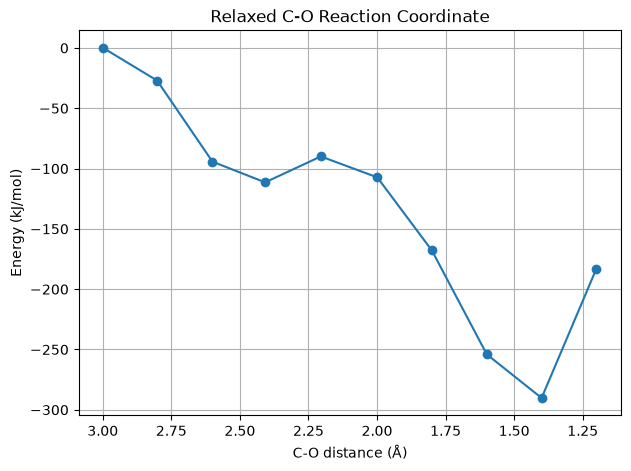

In [4]:
# Reconstructing those energies
with open("optimized_mols.pkl", "rb") as f:
    optimized_molecules_from_file = pickle.load(f)
    
Iwantreconstructedenergies = True
if Iwantreconstructedenergies:
    energies = []
    for i, mol in enumerate(optimized_molecules_from_file):
        mf = scf.RHF(mol)
        energy = mf.kernel(); #print(energy)
        energies.append(energy)
    energies_kj=(energies-energies[0])*2626
    
    # Plotting the energies (should look the same as the explicitly stored energies)
    plt.figure(figsize=(7,5))
    plt.plot(actual_distances,energies_kj,marker="o")
    plt.gca().invert_xaxis()
    plt.xlabel("C-O distance (Å)")
    plt.ylabel("Energy (kJ/mol)")
    plt.title("Relaxed C-O Reaction Coordinate")
    plt.grid(True)
    plt.show()

    with open("optimized_mfs.pkl", "rb") as f:
        mean_field_objects_from_file = pickle.load(f)

### Stringing together all the frames to create an xyz "trajectory" file
Useful for importing by other code, like ChimeraX.

In [5]:
Iwanttrajectory = True
if Iwanttrajectory:
    # Get names of the individual frame files
    xyz_files = sorted(glob.glob("xyz_frames/frame_*.xyz"))
    print("Number of XYZ files:", len(xyz_files))
    print(xyz_files)
    
    # Use the first file to determine the number of atoms
    uframe = mda.Universe(xyz_files[0], format="XYZ")
    n_atoms = uframe.atoms.n_atoms
    
    # Specify the name of the trajectory file
    xyz_trajectory = "trajectory.xyz"
    
    # String the xyz files together
    with XYZWriter(xyz_trajectory, n_atoms=n_atoms) as w:
        for i, f in enumerate(xyz_files):
            # print("Working on frame/file", i, f)
    
            uframe = mda.Universe(f, format="XYZ")
    
            for ts in uframe.trajectory:
                w.write(uframe.atoms)
    
    # Check
    u = mda.Universe(xyz_trajectory, format="XYZ")
    print("\nNumber of frames in", xyz_trajectory, "is", len(u.trajectory))

Number of XYZ files: 10
['xyz_frames/frame_000.xyz', 'xyz_frames/frame_001.xyz', 'xyz_frames/frame_002.xyz', 'xyz_frames/frame_003.xyz', 'xyz_frames/frame_004.xyz', 'xyz_frames/frame_005.xyz', 'xyz_frames/frame_006.xyz', 'xyz_frames/frame_007.xyz', 'xyz_frames/frame_008.xyz', 'xyz_frames/frame_009.xyz']

Number of frames in trajectory.xyz is 10


### Get a pdb version of each xyz file

In [6]:
Iwantpdbfiles = True
if Iwantpdbfiles:
    for xyz_file in xyz_files:
        u = mda.Universe(xyz_file, format="XYZ")
        pdb_file = os.path.splitext(xyz_file)[0] + ".pdb"; #print(pdb_file)
        with PDBWriter(pdb_file, multiframe=False) as w:
            w.write(u.atoms)

/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn(
/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'resnames' Using default value of 'UNK'
  warnings.warn(
/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn(
/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn(
/home/chemistry/venvs/jupyter/lib

### Choose a frame (and visualize it)

In [7]:
iframe = 0
# iframe = 0
xyzfile = xyz_files[iframe]
print(xyzfile)
viewer = megane.view_traj(xyzfile)
viewer

xyz_frames/frame_000.xyz


### Make orbitals for this frame

In [ ]:
Makeneworbitals = True
cube_folder = "cubes_for_frame"+str(iframe)
mol = optimized_molecules_from_file[iframe]
mf = mean_field_objects_from_file[iframe]
nbasis, norbs = np.shape(mf.mo_coeff)
print("nbasis, norbs =", nbasis, norbs)

# Identify the HOMO
n_occ = mol.nelectron // 2  # Number of occupied orbitals
print("HOMO =", n_occ)

orbital_energies = mf.mo_energy  # Get the orbital energies
homo_energy = orbital_energies[n_occ - 1]
print("Energy of HOMO =", homo_energy)

os.makedirs(cube_folder, exist_ok=True)
orbital_filenames = []
for iorb in range(norbs):
    filename = cube_folder+'/orbital_'+str(iorb)+'.cube'
    orbital_filenames.append(filename)
    if Makeneworbitals:
        print("Making orbital ", filename)
        cubegen.orbital(
            mol,
            filename,
            mf.mo_coeff[:, iorb],
            resolution=.3
        )
    else:
        print("Assuming orbital ", filename+" already exists")

nbasis, norbs = 104 104
HOMO = 43
Energy of HOMO = -0.22354027784767627
Making orbital  cubes_for_frame0/orbital_0.cube
Making orbital  cubes_for_frame0/orbital_1.cube
Making orbital  cubes_for_frame0/orbital_2.cube
Making orbital  cubes_for_frame0/orbital_3.cube
Making orbital  cubes_for_frame0/orbital_4.cube
Making orbital  cubes_for_frame0/orbital_5.cube
Making orbital  cubes_for_frame0/orbital_6.cube
Making orbital  cubes_for_frame0/orbital_7.cube
Making orbital  cubes_for_frame0/orbital_8.cube
Making orbital  cubes_for_frame0/orbital_9.cube
Making orbital  cubes_for_frame0/orbital_10.cube
Making orbital  cubes_for_frame0/orbital_11.cube
Making orbital  cubes_for_frame0/orbital_12.cube
Making orbital  cubes_for_frame0/orbital_13.cube
Making orbital  cubes_for_frame0/orbital_14.cube
Making orbital  cubes_for_frame0/orbital_15.cube
Making orbital  cubes_for_frame0/orbital_16.cube
Making orbital  cubes_for_frame0/orbital_17.cube
Making orbital  cubes_for_frame0/orbital_18.cube
Making 

### Plot orbitals

In [ ]:
for iorb in range(0,n_occ,1):
    orbitalcubefile = orbital_filenames[iorb]
    print("focusing on the orbital in", orbitalcubefile)
    
    info = read_cube_grid_info(orbitalcubefile)
    display(info)
    
    fig = go.Figure()
    fig.layout.scene.camera.projection.type = "orthographic"
    fig.update_layout(width=700, height=700)
    fig.update_layout(
        scene=dict(
            aspectmode='manual',  # Set to manual to use custom aspect ratio
            aspectratio=dict(x=1, y=1, z=1)  # Set equal aspect ratio
    ))
    add_atoms(mol,fig)
    add_an_orbital(orbital_filenames[iorb],fig,info)
    fig.show()
